In [1]:
# Step 1: Install FFTW
!apt-get install libfftw3-dev
!apt-get install libfftw3-mpi-dev
#!pip install cython==3.0.1
# Step 2: Set paths for Dedalus installation
import os
import matplotlib.pyplot as plt
os.environ['MPI_INCLUDE_PATH'] = "/usr/lib/x86_64-linux-gnu/openmpi/include"
os.environ['MPI_LIBRARY_PATH'] = "/usr/lib/x86_64-linux-gnu"
os.environ['FFTW_INCLUDE_PATH'] = "/usr/include"
os.environ['FFTW_LIBRARY_PATH'] = "/usr/lib/x86_64-linux-gnu"


# Step 3: Install Dedalus using pip
!echo "Cython<3" > cython_constraint.txt
!CC=mpicc PIP_CONSTRAINT=cython_constraint.txt pip3 install --no-cache http://github.com/dedalusproject/dedalus/zipball/master/
#!CC=mpicc PIP_CONSTRAINT=cython_constraint.txt pip install dedalus

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as ani
import dedalus.public as de
from dedalus.extras import flow_tools
from dedalus.tools import post
import shutil
import random
import time
import h5py
import pathlib
import logging

logger = logging.getLogger('2D RB Convection')

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  libfftw3-bin libfftw3-double3 libfftw3-long3 libfftw3-quad3 libfftw3-single3
Suggested packages:
  libfftw3-doc
The following NEW packages will be installed:
  libfftw3-bin libfftw3-dev libfftw3-double3 libfftw3-long3 libfftw3-quad3 libfftw3-single3
0 upgraded, 6 newly installed, 0 to remove and 49 not upgraded.
Need to get 4,654 kB of archives.
After this operation, 24.7 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 libfftw3-double3 amd64 3.3.8-2ubuntu8 [770 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libfftw3-long3 amd64 3.3.8-2ubuntu8 [335 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/main amd64 libfftw3-quad3 amd64 3.3.8-2ubuntu8 [614 kB]
Get:4 http://archive.ubuntu.com/ubuntu jammy/main amd64 libfftw3-single3 amd64 3.3.8-2ubuntu8 [800 kB]
Get:5 http://archive.ub

ModuleNotFoundError: No module named 'dedalus'

In [ ]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
# clean up the destination files
!rm -rf /content/gdrive/MyDrive/website-hugo/chaos_and_predictability/week3/RB2D/simulation/snapshots

In [ ]:

import dedalus.public as d3
import logging
# Parameters
Lx, Lz = 4, 1
Nx, Nz = 256, 64
Rayleigh = 2e6
Prandtl = 1
dealias = 3/2
stop_sim_time = 50
timestepper = d3.RK222
max_timestep = 0.125
dtype = np.float64

# Bases
coords = d3.CartesianCoordinates('x', 'z')
dist = d3.Distributor(coords, dtype=dtype)
xbasis = d3.RealFourier(coords['x'], size=Nx, bounds=(0, Lx), dealias=dealias)
zbasis = d3.ChebyshevT(coords['z'], size=Nz, bounds=(0, Lz), dealias=dealias)

# Fields
p = dist.Field(name='p', bases=(xbasis,zbasis))
b = dist.Field(name='b', bases=(xbasis,zbasis))
u = dist.VectorField(coords, name='u', bases=(xbasis,zbasis))
tau_p = dist.Field(name='tau_p')
tau_b1 = dist.Field(name='tau_b1', bases=xbasis)
tau_b2 = dist.Field(name='tau_b2', bases=xbasis)
tau_u1 = dist.VectorField(coords, name='tau_u1', bases=xbasis)
tau_u2 = dist.VectorField(coords, name='tau_u2', bases=xbasis)

# Substitutions
kappa = (Rayleigh * Prandtl)**(-1/2)
nu = (Rayleigh / Prandtl)**(-1/2)
x, z = dist.local_grids(xbasis, zbasis)
ex, ez = coords.unit_vector_fields(dist)
lift_basis = zbasis.derivative_basis(1)
lift = lambda A: d3.Lift(A, lift_basis, -1)
grad_u = d3.grad(u) + ez*lift(tau_u1) # First-order reduction
grad_b = d3.grad(b) + ez*lift(tau_b1) # First-order reduction

# Problem
# First-order form: "div(f)" becomes "trace(grad_f)"
# First-order form: "lap(f)" becomes "div(grad_f)"
problem = d3.IVP([p, b, u, tau_p, tau_b1, tau_b2, tau_u1, tau_u2], namespace=locals())
problem.add_equation("trace(grad_u) + tau_p = 0")
problem.add_equation("dt(b) - kappa*div(grad_b) + lift(tau_b2) = - u@grad(b)")
problem.add_equation("dt(u) - nu*div(grad_u) + grad(p) - b*ez + lift(tau_u2) = - u@grad(u)")
problem.add_equation("b(z=0) = Lz")
problem.add_equation("u(z=0) = 0")
problem.add_equation("b(z=Lz) = 0")
problem.add_equation("u(z=Lz) = 0")
problem.add_equation("integ(p) = 0") # Pressure gauge

# Solver
solver = problem.build_solver(timestepper)
solver.stop_sim_time = stop_sim_time

# Initial conditions
b.fill_random('g', seed=42, distribution='normal', scale=1e-3) # Random noise
b['g'] *= z * (Lz - z) # Damp noise at walls
b['g'] += Lz - z # Add linear background

# Analysis
snapshots = solver.evaluator.add_file_handler('snapshots', sim_dt=0.25, max_writes=50)
snapshots.add_task(b, name='buoyancy')
snapshots.add_task(-d3.div(d3.skew(u)), name='vorticity')

# CFL
CFL = d3.CFL(solver, initial_dt=max_timestep, cadence=10, safety=0.5, threshold=0.05,
             max_change=1.5, min_change=0.5, max_dt=max_timestep)
CFL.add_velocity(u)

# Flow properties
flow = d3.GlobalFlowProperty(solver, cadence=10)
flow.add_property(np.sqrt(u@u)/nu, name='Re')

# Main loop
startup_iter = 10
try:
    logger.info('Starting main loop')
    while solver.proceed:
        timestep = CFL.compute_timestep()
        solver.step(timestep)
        if (solver.iteration-1) % 10 == 0:
            max_Re = flow.max('Re')
            logger.info('Iteration=%i, Time=%e, dt=%e, max(Re)=%f' %(solver.iteration, solver.sim_time, timestep, max_Re))
except:
    logger.error('Exception raised, triggering end of main loop.')
    raise
finally:
    solver.log_stats()



DEBUG:distributor:Mesh: []
DEBUG:problems:Adding equation 0
DEBUG:problems:  LHS: Trace(Grad(u) + ez*<Field 135388423830016>*tau_u1) + C(C(tau_p))
DEBUG:problems:  RHS: 0
DEBUG:problems:  condition: True
DEBUG:problems:  M: 0
DEBUG:problems:  L: Trace(Grad(u) + ez*<Field 135388423830016>*tau_u1) + C(C(tau_p))
DEBUG:problems:  F: <Field 135388423816000>
DEBUG:problems:Adding equation 1
DEBUG:problems:  LHS: C(dt(b)) + -1*0.0007071067811865475*Div(Grad(b) + ez*<Field 135388423830016>*tau_b1) + C(<Field 135388423830016>*tau_b2)
DEBUG:problems:  RHS: -1*u@Grad(b)
DEBUG:problems:  condition: True
DEBUG:problems:  M: C(b)
DEBUG:problems:  L: -1*0.0007071067811865475*Div(Grad(b) + ez*<Field 135388423830016>*tau_b1) + C(<Field 135388423830016>*tau_b2)
DEBUG:problems:  F: C(-1*u@Grad(b))
DEBUG:problems:Adding equation 2
DEBUG:problems:  LHS: C(dt(u)) + -1*0.0007071067811865475*Div(Grad(u) + ez*<Field 135388423830016>*tau_u1) + C(Grad(p)) + C(-1*b*ez) + C(<Field 135388423830016>*tau_u2)
DEBUG:pr

2023-09-28 01:46:14,901 subsystems 0/1 INFO :: Building subproblem matrices 1/128 (~1%) Elapsed: 0s, Remaining: 24s, Rate: 5.3e+00/s


INFO:subsystems:Building subproblem matrices 13/128 (~10%) Elapsed: 1s, Remaining: 9s, Rate: 1.3e+01/s


2023-09-28 01:46:15,714 subsystems 0/1 INFO :: Building subproblem matrices 13/128 (~10%) Elapsed: 1s, Remaining: 9s, Rate: 1.3e+01/s


INFO:subsystems:Building subproblem matrices 26/128 (~20%) Elapsed: 2s, Remaining: 8s, Rate: 1.4e+01/s


...

INFO:solvers:CPU time (iter 10-end): 0.03416 cpu-hr


2023-09-28 01:48:29,310 solvers 0/1 INFO :: CPU time (iter 10-end): 0.03416 cpu-hr


INFO:solvers:Speed: 1.077e+06 mode-stages/cpu-sec


2023-09-28 01:48:29,312 solvers 0/1 INFO :: Speed: 1.077e+06 mode-stages/cpu-sec


KeyboardInterrupt: ignored

In [ ]:
f = h5py.File('/content/snapshots/snapshots_s2.h5', 'r')
T = f['tasks']['buoyancy']
np.shape(T) # dimension = time, x,z


(35, 256, 64)

DEBUG:matplotlib.colorbar:locator: <matplotlib.ticker.FixedLocator object at 0x7b22896211e0>


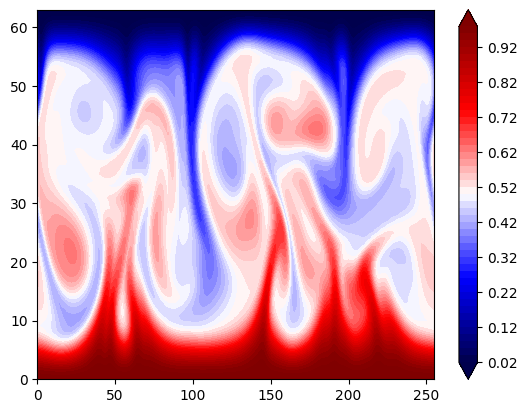

In [ ]:
t=34
plt.figure()
cs=plt.contourf(np.transpose(T[t,:,:]),50,cmap='seismic',extend='both')
plt.colorbar(cs)